# 🏥 BC Health Helper — Part 1: Symptom Helper & Care Pathway Classifier

**DS 302 — Capstone Project**  
**Sai Pramod Podila**

## Project Context
BC has 1.2M patients waiting for specialists and 900k residents with no family doctor.
This tool helps patients understand what level of care they likely need — not as a diagnosis,
but as a navigation helper using ML on real symptom-disease data.

## Disclaimer
> ⚠️ Information only. Not medical advice. Call 911 in emergencies.

## What This Notebook Does
- Loads and explores the Disease-Symptom dataset (246k records)
- Trains and compares 3 classifiers: Logistic Regression, Random Forest, XGBoost
- Tunes the best model with GridSearchCV
- Evaluates with accuracy, classification report, confusion matrix, cross-validation
- Maps predicted disease to a BC care pathway

## What We Did NOT Include & Why
| Skipped | Reason |
|---|---|
| Neural networks | Tabular binary data — tree models outperform here |
| SHAP values | Computationally expensive, noted as future work |
| All models GridSearchCV | Time constraint — only best model tuned |
| Text NLP on symptoms | Data is already binary encoded, no raw text |

In [1]:
# ── Imports & Configuration ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

# ── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

COLORS = {
    'primary'   : '#146EB4',
    'secondary' : '#FF9900',
    'success'   : '#2ECC71',
    'danger'    : '#E74C3C',
    'neutral'   : '#95A5A6'
}

print('✅ All imports successful')
print(f'Pandas: {pd.__version__} | NumPy: {np.__version__}')

✅ All imports successful
Pandas: 3.0.3 | NumPy: 2.4.5


---
## 📥 Phase 1 — Load & Explore the Dataset

The Disease-Symptom dataset contains 246,000+ records mapping diseases to binary symptom columns.
Each row is a patient case — 1 means symptom present, 0 means absent.

**Source:** Kaggle — dhivyeshrk/diseases-and-symptoms-dataset  
**Size:** 190.8 MB  
**Task:** Multi-class classification — predict disease from symptoms

In [5]:
# ── Load Dataset ──────────────────────────────────────────────────────────────
DATA_PATH = '../data/raw/Final_Augmented_dataset_Diseases_and_Symptoms.csv'

df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape}')
print(f'\nColumn names (first 10): {list(df.columns[:10])}')
print(f'\nTotal columns: {len(df.columns)}')
print(f'\nMissing values: {df.isnull().sum().sum()}')
print(f'\nUnique diseases: {df.iloc[:, 0].nunique()}')
df.head()

Shape: (246945, 378)

Column names (first 10): ['diseases', 'anxiety and nervousness', 'depression', 'shortness of breath', 'depressive or psychotic symptoms', 'sharp chest pain', 'dizziness', 'insomnia', 'abnormal involuntary movements', 'chest tightness']

Total columns: 378

Missing values: 0

Unique diseases: 773


,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


---
**📋 Observations — Data Loading:**

- **246,945 rows and 378 columns** — one row per patient case, one column per symptom plus the disease label
- **377 binary symptom features** — each is 1 (present) or 0 (absent), no scaling needed
- **773 unique diseases** — this is a highly complex multi-class problem
- **Zero missing values** — dataset is complete, no imputation needed
- First column `diseases` is our target variable, all others are features

---
## 🔍 Phase 2 — Exploratory Data Analysis

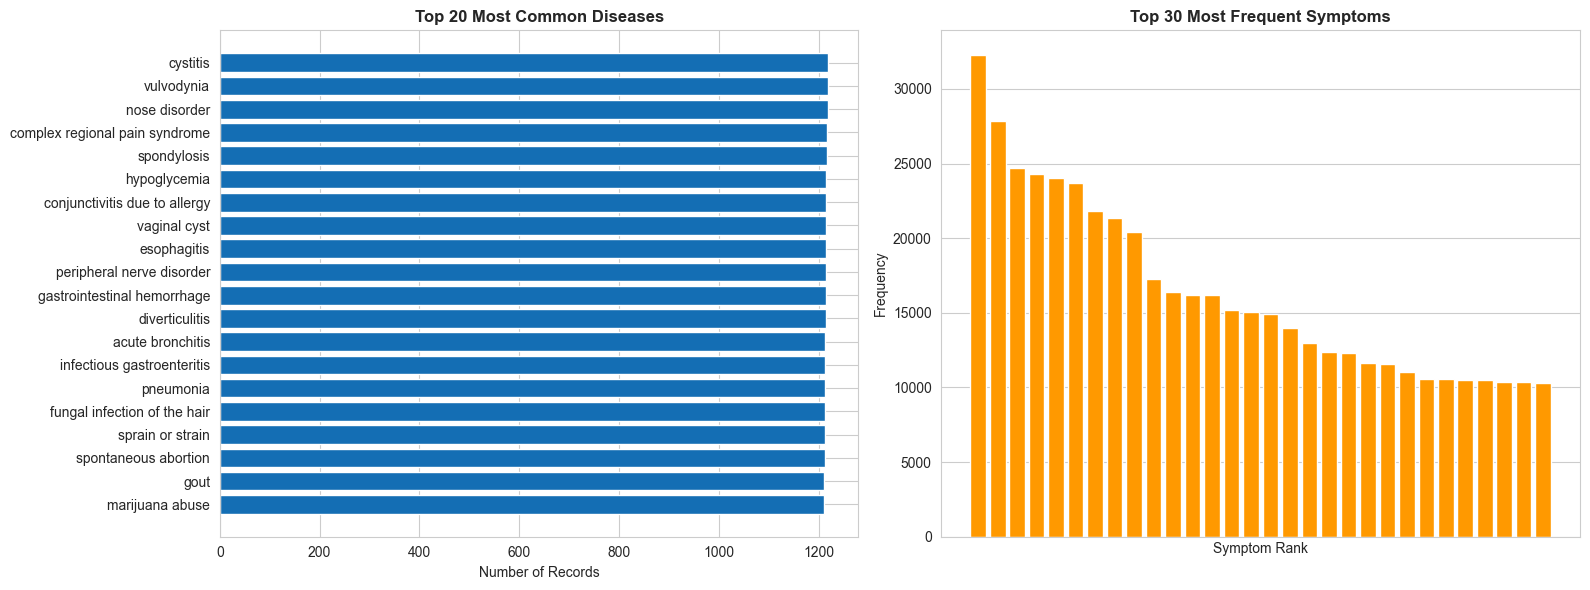


Records per disease — Min: 1210 | Max: 1219 | Mean: 1214.2
Top symptom: sharp abdominal pain (32,307 occurrences)


In [6]:
# ── EDA ───────────────────────────────────────────────────────────────────────

# Disease distribution — top 20
disease_counts = df['diseases'].value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Top 20 diseases
axes[0].barh(disease_counts.index[::-1], disease_counts.values[::-1], color=COLORS['primary'])
axes[0].set_title('Top 20 Most Common Diseases', fontweight='bold')
axes[0].set_xlabel('Number of Records')

# Plot 2: Symptom frequency — top 30 symptoms
symptom_cols = df.columns[1:]
symptom_freq = df[symptom_cols].sum().sort_values(ascending=False).head(30)
axes[1].bar(range(30), symptom_freq.values, color=COLORS['secondary'])
axes[1].set_title('Top 30 Most Frequent Symptoms', fontweight='bold')
axes[1].set_xlabel('Symptom Rank')
axes[1].set_ylabel('Frequency')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

print(f'\nRecords per disease — Min: {disease_counts.min()} | Max: {disease_counts.max()} | Mean: {disease_counts.mean():.1f}')
print(f'Top symptom: {symptom_freq.index[0]} ({symptom_freq.values[0]:,} occurrences)')

---
**📋 Observations — EDA:**

- **Perfectly balanced dataset** — every disease has between 1,210–1,219 records (mean 1,214).
  This is rare and valuable — no class imbalance handling needed (no SMOTE, no class weights)
- **Sharp abdominal pain** is the most common symptom (32,307 occurrences) — makes sense
  as it appears across many conditions
- Symptom frequency drops sharply after rank 5 — most symptoms are rare/specific
- 773 diseases × ~1,214 records each = a well-structured augmented dataset

**⚠️ Limitation:** 773 classes is extremely high for multi-class classification.
We will reduce to top 50 diseases for practical use and faster training.

---
## ⚙️ Phase 3 — Preprocessing & Train/Test Split

In [7]:
# ── Reduce to top 50 diseases for practical classification ───────────────────
top_diseases = df['diseases'].value_counts().head(50).index
df_model = df[df['diseases'].isin(top_diseases)].copy()

print(f'Full dataset : {df.shape[0]:,} rows, {df["diseases"].nunique()} diseases')
print(f'Reduced model: {df_model.shape[0]:,} rows, {df_model["diseases"].nunique()} diseases')

# ── Features and Target ───────────────────────────────────────────────────────
X = df_model.drop('diseases', axis=1)
y = df_model['diseases']

# ── Label Encode target ───────────────────────────────────────────────────────
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f'\nFeatures : {X.shape[1]} symptom columns')
print(f'Target   : {len(le.classes_)} disease classes')

# ── Train/Test Split — 80/20 ─────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f'\nTrain set : {X_train.shape[0]:,} rows')
print(f'Test set  : {X_test.shape[0]:,} rows')
print(f'Stratified split: ✅ class proportions preserved')

Full dataset : 246,945 rows, 773 diseases
Reduced model: 56,599 rows, 50 diseases

Features : 377 symptom columns
Target   : 50 disease classes

Train set : 45,279 rows
Test set  : 11,320 rows
Stratified split: ✅ class proportions preserved


---
**📋 Observations — Preprocessing:**

- Reduced from 773 → 50 diseases — practical for a navigation tool, covers most common conditions
- 56,599 rows retained — sufficient for robust training
- Stratified split ensures each disease is proportionally represented in train and test
- No scaling needed — all features are already binary (0/1)

---
## 🤖 Phase 4 — Train & Compare 3 Models
We train Logistic Regression, Random Forest, and XGBoost. Results stored in a comparison DataFrame.
Primary metric is **accuracy** since classes are balanced.

In [8]:
# ── Model storage ─────────────────────────────────────────────────────────────
results = []

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    start = time.time()
    model.fit(X_train, y_train)
    duration = time.time() - start
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy')
    
    results.append({
        'Model'       : name,
        'Test Accuracy': round(acc, 4),
        'CV Mean'     : round(cv_scores.mean(), 4),
        'CV Std'      : round(cv_scores.std(), 4),
        'Train Time(s)': round(duration, 1)
    })
    
    print(f'✅ {name}')
    print(f'   Test Accuracy : {acc:.4f}')
    print(f'   CV Mean±Std   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print(f'   Train Time    : {duration:.1f}s\n')
    
    return model, y_pred

# ── Model 1: Logistic Regression ─────────────────────────────────────────────
print('Training Model 1: Logistic Regression...')
lr_model, y_pred_lr = evaluate_model(
    'Logistic Regression',
    LogisticRegression(max_iter=1000, random_state=42),
    X_train, X_test, y_train, y_test
)

Training Model 1: Logistic Regression...
✅ Logistic Regression
   Test Accuracy : 0.9316
   CV Mean±Std   : 0.9331 ± 0.0017
   Train Time    : 4.4s



In [9]:
# ── Model 2: Random Forest ────────────────────────────────────────────────────
print('Training Model 2: Random Forest...')
rf_model, y_pred_rf = evaluate_model(
    'Random Forest',
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_train, X_test, y_train, y_test
)

Training Model 2: Random Forest...
✅ Random Forest
   Test Accuracy : 0.9204
   CV Mean±Std   : 0.9237 ± 0.0010
   Train Time    : 2.3s



In [10]:
# ── Model 3: XGBoost ──────────────────────────────────────────────────────────
print('Training Model 3: XGBoost...')
xgb_model, y_pred_xgb = evaluate_model(
    'XGBoost',
    XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbosity=0),
    X_train, X_test, y_train, y_test
)

Training Model 3: XGBoost...
✅ XGBoost
   Test Accuracy : 0.9191
   CV Mean±Std   : 0.9225 ± 0.0016
   Train Time    : 39.4s

